In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import plotly.graph_objects as go
import os
import re

# for bessel functions and curve fitting
from scipy.optimize import curve_fit
from scipy import special

# plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amssymb}"
})

def sci_notation_latex(x, precision=2):
    mantissa, exp = f"{x:.{precision}e}".split("e")
    return rf"{mantissa} \cdot 10^{{{int(exp)}}}"

# constants
q = 1.602e-19     # Charge of electron [C]
k_eV = 8.617e-5   # Boltzmann constant [eV/K]
k_J = 1.381e-23   # Boltzmann constant [J/K]
T = 295.15        # Temperature [K] -> 22 °C
A_Rich = 147      # Richardson constant for 4H-SiC (A/cm²K²)

In [2]:
def plot_IV_curves(list_of_measurements, folder_path):
    colors = plt.get_cmap("viridis", len(list_of_measurements))
    plt.figure(figsize=(8, 5))

    for i, key in enumerate(list_of_measurements.keys()):
        plt.plot(list_of_measurements[key]['delta_V'], list_of_measurements[key]['Iin']*1000, 'o-', color=colors(i), label=f"{key} $\\mu m$")

    plt.xlabel("Voltage / V")
    plt.ylabel("Current / mA")
    # plt.xlim(-0.5, 0.5)
    # plt.title(os.path.basename(folder_path))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    # plt.savefig(os.path.join(folder_path, 'IV_plot.pdf'), dpi=300)
    # plt.savefig(os.path.join(folder_path, 'IV_plot.png'), dpi=300)
    plt.show()

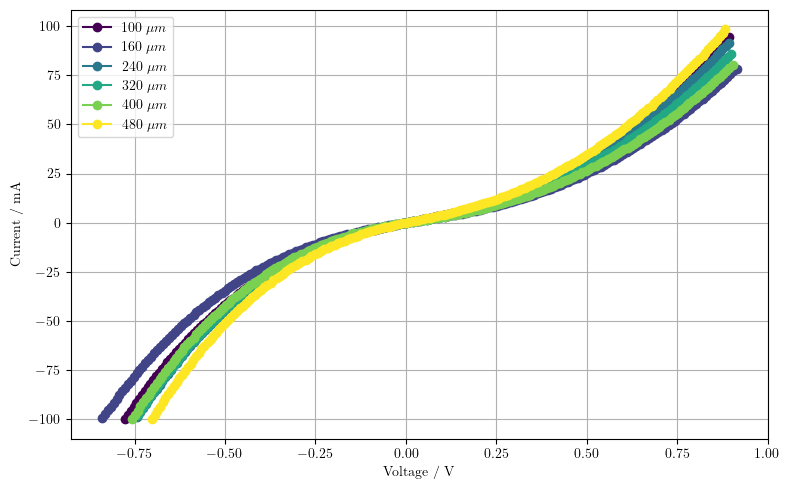

In [3]:
from readTLMData import TLMREADER

folder_path = r"../Data/IV/cTLM_final_NiSi_850/[processname=cTLM_Ni][structure=CTLM][ri=150][description=Mitte]"
list_of_measurements = TLMREADER(folder_path).readTLMData()
list_of_measurements = dict(sorted(list_of_measurements.items()))

plot_IV_curves(list_of_measurements, folder_path)

calculate n:

$n = \frac{q}{mkT}$

and saturation current

$I_0 = e^{Intersect}$

get barrier hight using the values for $I_0$

$\Phi_B=\frac{kT}{q} \ln{\frac{AA^*T^2}{I_0}}$

In [9]:
def get_diode_params(m, Intersect):
    A = np.pi*0.015**2          # Contact area in cm²

    n = q/(m*k_J*T)
    I_0 = np.exp(Intersect)
    print('n =', n, 'I_0 =', I_0, '=', "{:e}".format(I_0))
    
    barrier = ((k_J*T)/q) * np.log((A*A_Rich*T**2)/I_0)
    print('barrier=', barrier)
    return n, I_0, barrier

m =  3.2189802534709373 I_0 =  -5.118971302332023
n = 12.209777028578205 I_0 = 0.005982173578876495 = 5.982174e-03
barrier= 0.36205072750541445


TypeError: 'Series' object is not callable

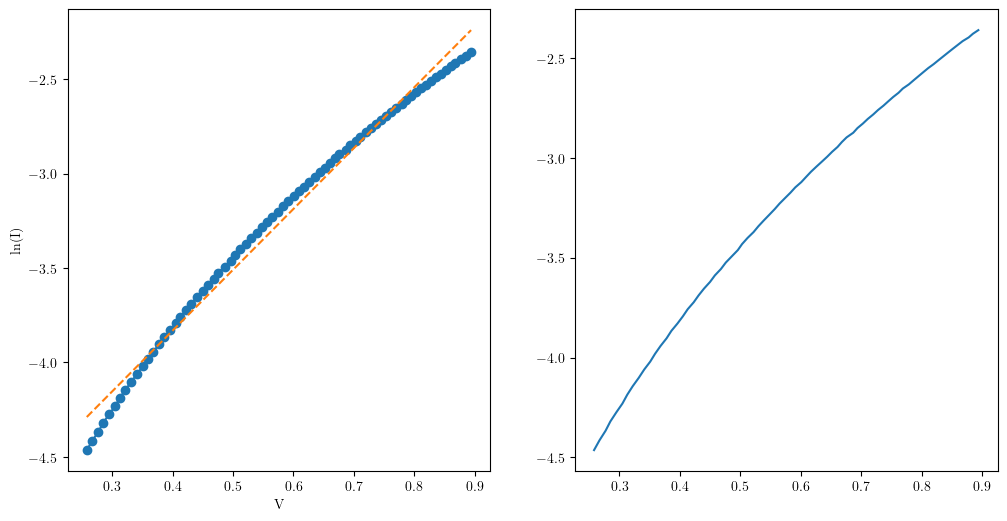

In [10]:
def diode_model(n, I_0, V):
    exponent = (q*V)(n*k_J*T)
    return I_0*(np.exp(exponent)-1)

V_100 = list_of_measurements[100]['delta_V']
V_fit = V_100.loc[V_100>0.25]
I_100 = list_of_measurements[100]['Iin'].iloc[V_fit.index]
I_fit = np.log(I_100)

m, Intersect = np.polyfit(V_fit, I_fit, 1)
print('m = ', m, 'I_0 = ', Intersect)
n, I_0, barrier = get_diode_params(m, Intersect)

fig = plt.figure(figsize=(12,6))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(V_fit, I_fit, '-o')
ax1.plot(V_fit, m*V_fit+Intersect, linestyle='--')
ax1.set_xlabel('V')
ax1.set_ylabel('ln(I)')

ax2 = fig.add_subplot(1,2,2)
ax2.plot(V_fit, I_fit, label='Original Data')
ax2.plot(V_fit, diode_model(n, I_0, V_fit), label='Diode Model')

plt.show()